In [5]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Download and prepare the data
# Menggunakan 'on_bad_lines' untuk mengatasi error tokenizing data
data = pd.read_csv("C:/Uner/Semester 5/Data Mining II/Coolyeah/TM8/SPAM text message 20170820 - Data.csv")

# Tampilkan beberapa baris pertama untuk memahami struktur data
print(data.head())

# 2. Preprocessing text (Tokenization, Stopword Removal, Stemming)
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

def preprocess_text(text):
    # Tokenization
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords and stem the words
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and word.isalpha()]
    
    return " ".join(tokens)

# Assuming the 'v2' column contains the text and 'label' is the spam label (ham or spam)
data['processed_text'] = data['v2'].apply(preprocess_text)

# 3. Vektorisasi menggunakan TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['processed_text']).toarray()

# 4. Encode labels (Assuming 'label' column contains 'spam' and 'ham' as labels)
y = pd.get_dummies(data['label']).values  # 'ham' = 0, 'spam' = 1

# 5. Split data (70% train, 20% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)  # 10% test

# 6. Membangun Model Neural Network dengan TensorFlow
model = Sequential()

# Input Layer
model.add(Dense(512, input_dim=X_train.shape[1], activation='relu'))

# Hidden Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Regularization to avoid overfitting

# Output Layer
model.add(Dense(y_train.shape[1], activation='softmax'))  # Softmax for binary classification (ham/spam)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# 7. Melatih Model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))

# 8. Evaluasi Model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# 9. Menampilkan Hasil Evaluasi
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))

print("Confusion Matrix:")
print(confusion_matrix(y_test_classes, y_pred_classes))

# 10. Plotting the training history (optional)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


[nltk_data] Downloading package punkt to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


KeyError: 'v2'

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
Kolom yang tersedia dalam data: Index(['Category', 'Message'], dtype='object')


[nltk_data] Downloading package punkt to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8478 - loss: 0.4147 - val_accuracy: 0.9425 - val_loss: 0.1504
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9730 - loss: 0.1038 - val_accuracy: 0.9794 - val_loss: 0.0768
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9972 - loss: 0.0115 - val_accuracy: 0.9811 - val_loss: 0.0799
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9998 - loss: 0.0033 - val_accuracy: 0.9829 - val_loss: 0.0851
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9820 - val_loss: 0.0907
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 0.9820 - val_loss: 0.0899
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9999 - loss: 5.9253e-04 - val_accuracy: 0.9829 - val_loss: 0.0853
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9820

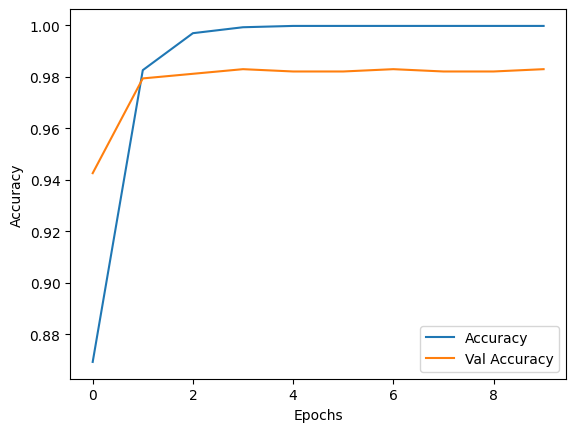

In [6]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Download and prepare the data
# Menggunakan 'on_bad_lines' untuk mengatasi error tokenizing data
data = pd.read_csv("C:/Uner/Semester 5/Data Mining II/Coolyeah/TM8/SPAM text message 20170820 - Data.csv")

# Tampilkan beberapa baris pertama untuk memahami struktur data
print(data.head())

# 2. Cek nama kolom
print("Kolom yang tersedia dalam data:", data.columns)

# 3. Preprocessing text (Tokenization, Stopword Removal, Stemming)
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

def preprocess_text(text):
    # Tokenization
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords and stem the words
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and word.isalpha()]
    
    return " ".join(tokens)

# Misalnya, jika kolom yang berisi teks adalah 'Message' dan labelnya ada di 'Category', sesuaikan seperti ini:
data['processed_text'] = data['Message'].apply(preprocess_text)

# 4. Vektorisasi menggunakan TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['processed_text']).toarray()

# 5. Encode labels (Assuming 'Category' column contains 'spam' and 'ham' as labels)
y = pd.get_dummies(data['Category']).values  # 'ham' = 0, 'spam' = 1

# 6. Split data (70% train, 20% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)  # 10% test

# 7. Membangun Model Neural Network dengan TensorFlow
model = Sequential()

# Input Layer
model.add(Dense(512, input_dim=X_train.shape[1], activation='relu'))

# Hidden Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Regularization to avoid overfitting

# Output Layer
model.add(Dense(y_train.shape[1], activation='softmax'))  # Softmax for binary classification (ham/spam)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# 8. Melatih Model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))

# 9. Evaluasi Model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# 10. Menampilkan Hasil Evaluasi
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))

print("Confusion Matrix:")
print(confusion_matrix(y_test_classes, y_pred_classes))

# 11. Plotting the training history (optional)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


[nltk_data] Downloading package punkt to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Epoch 1/10


C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8286 - loss: 0.4188 - val_accuracy: 0.9165 - val_loss: 0.1551
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9703 - loss: 0.1050 - val_accuracy: 0.9794 - val_loss: 0.0761
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9965 - loss: 0.0152 - val_accuracy: 0.9847 - val_loss: 0.0739
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9847 - val_loss: 0.0774
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 0.9856 - val_loss: 0.0786
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 0.9856 - val_loss: 0.0781
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9838 - val_loss: 0.0886
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9847 - val_loss: 0.

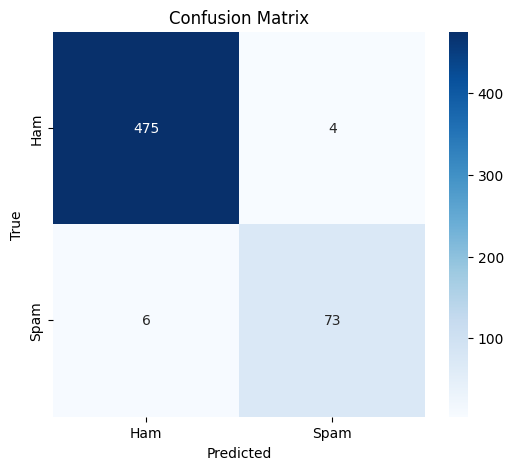

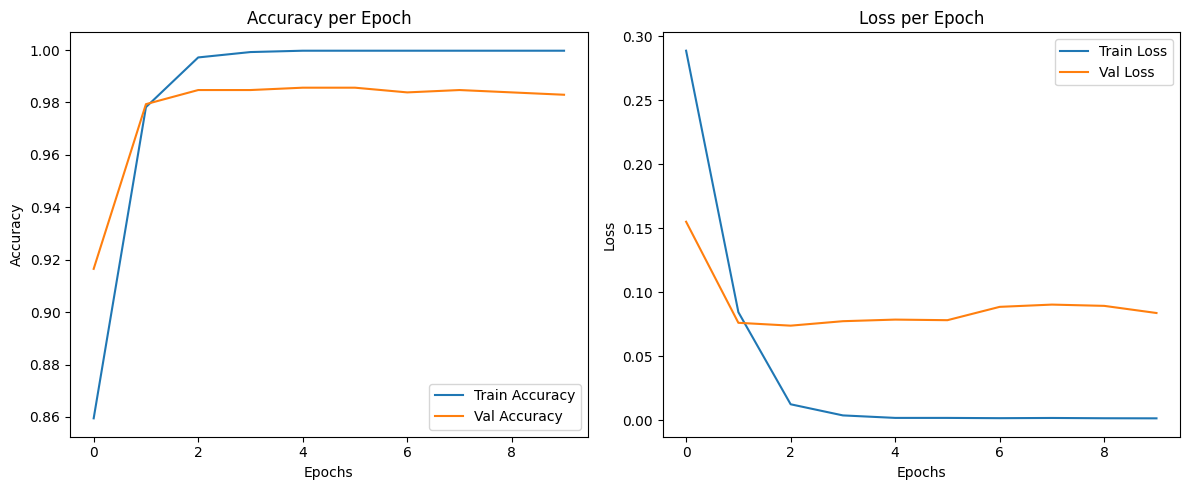

In [7]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download and prepare the data
# Menggunakan 'on_bad_lines' untuk mengatasi error tokenizing data
data = pd.read_csv("C:/Uner/Semester 5/Data Mining II/Coolyeah/TM8/SPAM text message 20170820 - Data.csv")

# Tampilkan beberapa baris pertama untuk memahami struktur data
print(data.head())

# 2. Preprocessing text (Tokenization, Stopword Removal, Stemming)
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

def preprocess_text(text):
    # Tokenization
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords and stem the words
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and word.isalpha()]
    
    return " ".join(tokens)

# Misalnya, jika kolom yang berisi teks adalah 'Message' dan labelnya ada di 'Category', sesuaikan seperti ini:
data['processed_text'] = data['Message'].apply(preprocess_text)

# 3. Vektorisasi menggunakan TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['processed_text']).toarray()

# 4. Encode labels (Assuming 'Category' column contains 'spam' and 'ham' as labels)
y = pd.get_dummies(data['Category']).values  # 'ham' = 0, 'spam' = 1

# 5. Split data (70% train, 20% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)  # 10% test

# 6. Membangun Model Neural Network dengan TensorFlow
model = Sequential()

# Input Layer
model.add(Dense(512, input_dim=X_train.shape[1], activation='relu'))

# Hidden Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Regularization to avoid overfitting

# Output Layer
model.add(Dense(y_train.shape[1], activation='softmax'))  # Softmax for binary classification (ham/spam)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# 7. Melatih Model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))

# 8. Evaluasi Model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# 9. Menampilkan Hasil Evaluasi
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# 10. Visualisasi Confusion Matrix dengan Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 11. Plotting the training history (Accuracy & Loss)
plt.figure(figsize=(12, 5))

# Subplot for Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Subplot for Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
